<a href="https://colab.research.google.com/github/Angappan95/langchain-practice/blob/main/101_personal_chef_agent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install langchain langchain-google-genai tavily-python tavily -q

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.6/67.6 kB 2.3 MB/s eta 0:00:00


In [4]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain.agents import create_agent
from langchain.messages import SystemMessage, HumanMessage, AIMessage
from langchain.tools import tool
from langgraph.checkpoint.memory import InMemorySaver
from tavily import TavilyClient
from google.colab import userdata

In [5]:
client = TavilyClient(api_key = userdata.get("TAVILY_API_KEY"))
def web_search(query: str):
    '''Searches given query and returns currated answer'''
    return client.search(query)

tools = [web_search]

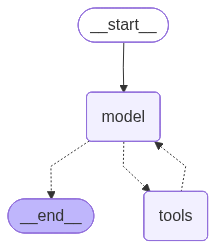

In [9]:
model = ChatGoogleGenerativeAI(model="gemini-3.1-flash-lite-preview", api_key=userdata.get("GOOGLE_API_KEY"))

memory = InMemorySaver()

system_prompt = "You will be given with list of left over items based on which search internet by using the tools provided and come up with best strucutred reciepies"

chef_agent = create_agent(model=model, system_prompt=system_prompt, checkpointer=memory, tools=tools)
chef_agent

In [10]:
config = {'configurable': {'thread_id': '101'}}

def ask_llm(stocks):
    messages = [
        HumanMessage(f"I have following items {stocks}")
    ]
    response = chef_agent.invoke({"messages": messages}, config=config)
    return response

In [11]:
response = ask_llm("Onion, Tomato, Eggs, spices")
print(response["messages"][-1].content[-1]['text'])

With onion, tomato, eggs, and spices, you have the foundation for some classic, delicious, and easy-to-make meals. Here are three distinct ways to prepare them, depending on the texture and style you prefer.

---

### 1. Shakshuka (Spiced Poached Eggs in Tomato Sauce)
This is a hearty, one-pan dish where eggs are gently poached in a rich, spiced tomato and onion base.

*   **Prep time:** 5 mins | **Cook time:** 15 mins
*   **Spices to use:** Cumin, paprika, chili powder/flakes, salt, and pepper.

**Instructions:**
1.  **Sauté:** Finely dice the onion and sauté in a pan with a little oil until translucent.
2.  **Make Sauce:** Add diced tomatoes and your spices. Cook over medium heat until the tomatoes break down and form a thick sauce.
3.  **Add Eggs:** Use a spoon to make small "wells" in the sauce. Crack an egg into each well.
4.  **Cook:** Cover the pan with a lid and cook on low heat for 5–7 minutes, or until the egg whites are set but the yolks are still runny.

---

### 2. Indian-

In [13]:
response = ask_llm("Give detailed reciepe of #2")
print(response["messages"][-1].content[-1]["text"])

### **Indian-Style Egg Bhurji (Spicy Scrambled Eggs)**

Egg Bhurji is a flavor-packed, savory dish that is incredibly popular in Indian households. Unlike standard scrambled eggs, this version features a "masala" (a spiced base) made by sautéing onions and tomatoes until they become soft and jammy, providing a deep, complex flavor.

*   **Servings:** 1–2
*   **Prep time:** 5 minutes
*   **Cook time:** 10 minutes

---

### **Ingredients**
*   **Eggs:** 3–4 large eggs
*   **Onion:** 1 medium (finely chopped)
*   **Tomato:** 1 medium (finely chopped)
*   **Oil/Butter:** 1 tablespoon
*   **Spices:**
    *   ½ teaspoon Turmeric powder (gives it the signature bright color)
    *   ½ to 1 teaspoon Chili powder (adjust to your heat preference)
    *   ½ teaspoon Cumin powder (optional, but recommended)
    *   Salt (to taste)
    *   *Optional:* A pinch of Garam Masala or black pepper for an extra kick

---

### **Step-by-Step Instructions**

#### **1. Prepare the Base**
*   Heat 1 tablespoon 

In [15]:
from pprint import pprint
pprint(response['messages'])

[HumanMessage(content='I have following items Onion, Tomato, Eggs, spices', additional_kwargs={}, response_metadata={}, id='14723ca3-e1b2-42c7-acf4-9c733df3035a'),
 AIMessage(content=[], additional_kwargs={'function_call': {'name': 'web_search', 'arguments': '{"query": "recipes using onion tomato eggs and spices"}'}, '__gemini_function_call_thought_signatures__': {'b3e12583-525c-4c95-99bc-9827ae9e5a8c': 'EjQKMgEMOdbHFZDLhLrfdnLBXxaI1JTM0GB1NTitqQW7L9oXy/ToC3ckKzCe82iuowZkIW29'}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite-preview', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019deea3-315e-7450-9d60-e75f8088b3cc-0', tool_calls=[{'name': 'web_search', 'args': {'query': 'recipes using onion tomato eggs and spices'}, 'id': 'b3e12583-525c-4c95-99bc-9827ae9e5a8c', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 89, 'output_tokens': 22, 'total_tokens': 111, 'input_token_details': {'cache_read': 0}}),
